# NB05: 유동인구 데이터 집계

**목적**: 36개월 행정동별 유동인구를 시간대/성별/연령별로 집계, 주문 잠재 고객군 식별

**입력**: `00_data/민간데이터/T22-*/T22/T22_GG_ADMI_FLOWPOP_*.csv` (36 files)  
**출력**: `processed/flow_pop_agg.parquet` (동별 유동인구 집계)

In [1]:
import pandas as pd
import numpy as np
import glob
from pathlib import Path

BASE = Path(r"C:\Users\jimin\Desktop\1_BITAmin_16기\1_Seongnam")
RAW = BASE / "00_data"
OUT = BASE / "processed"

# 유동인구 파일 탐색
fp_files = sorted(glob.glob(str(RAW / "민간데이터" / "T22*" / "T22" / "*.csv")))
print(f"총 유동인구 파일: {len(fp_files)}개")

총 유동인구 파일: 36개


## 1. 전체 파일 로드 및 합치기

파일당 ~7만 행으로 카드매출 대비 작아 전체 로드 가능

In [2]:
# 전체 파일 로드
dfs = []
for fpath in fp_files:
    df = pd.read_csv(fpath)
    # 파일명에서 연월 추출
    fname = Path(fpath).stem  # T22_GG_ADMI_FLOWPOP_202301_성남시
    ym = fname.split("_")[4]  # 202301
    df["ym"] = ym
    dfs.append(df)

df_fp = pd.concat(dfs, ignore_index=True)
print(f"전체 행 수: {len(df_fp):,}")
print(f"기간: {df_fp['ym'].min()} ~ {df_fp['ym'].max()}")
print(f"행정동 수: {df_fp['ADMI_CD'].nunique()}")
print(f"\n컬럼: {df_fp.columns.tolist()}")

전체 행 수: 2,590,644
기간: 202301 ~ 202512
행정동 수: 50

컬럼: ['ADMI_CD', 'CTY_NM', 'ADMI_NM', 'TIME_CD', 'FORN_GB', 'M_10_CNT', 'M_15_CNT', 'M_20_CNT', 'M_25_CNT', 'M_30_CNT', 'M_35_CNT', 'M_40_CNT', 'M_45_CNT', 'M_50_CNT', 'M_55_CNT', 'M_60_CNT', 'M_65_CNT', 'M_70_CNT', 'F_10_CNT', 'F_15_CNT', 'F_20_CNT', 'F_25_CNT', 'F_30_CNT', 'F_35_CNT', 'F_40_CNT', 'F_45_CNT', 'F_50_CNT', 'F_55_CNT', 'F_60_CNT', 'F_65_CNT', 'F_70_CNT', 'ETL_YMD', 'ym', 'ADMI_CD ', ' CTY_NM ', ' ADMI_NM ', ' TIME_CD ', ' FORN_GB ', ' M_10_CNT ', ' M_15_CNT ', ' M_20_CNT ', ' M_25_CNT ', ' M_30_CNT ', ' M_35_CNT ', ' M_40_CNT ', ' M_45_CNT ', ' M_50_CNT ', ' M_55_CNT ', ' M_60_CNT ', ' M_65_CNT ', ' M_70_CNT ', ' F_10_CNT ', ' F_15_CNT ', ' F_20_CNT ', ' F_25_CNT ', ' F_30_CNT ', ' F_35_CNT ', ' F_40_CNT ', ' F_45_CNT ', ' F_50_CNT ', ' F_55_CNT ', ' F_60_CNT ', ' F_65_CNT ', ' F_70_CNT ', ' ETL_YMD']


## 2. 성별/연령대 합산 → 동별-시간대 총 유동인구

In [3]:
# 성별/연령 컬럼 식별 (M_10_CNT ~ M_70_CNT, F_10_CNT ~ F_70_CNT)
male_cols = [c for c in df_fp.columns if c.startswith("M_") and c.endswith("_CNT")]
female_cols = [c for c in df_fp.columns if c.startswith("F_") and c.endswith("_CNT")]
pop_cols = male_cols + female_cols

print(f"남성 연령대: {male_cols}")
print(f"여성 연령대: {female_cols}")

# 총 유동인구 계산
df_fp["total_pop"] = df_fp[pop_cols].sum(axis=1)
df_fp["male_pop"] = df_fp[male_cols].sum(axis=1)
df_fp["female_pop"] = df_fp[female_cols].sum(axis=1)

# 배달 주문 핵심 연령대 (20~40대) 유동인구
young_cols = [c for c in pop_cols if any(c.startswith(f"{g}_{a}") for g in ["M","F"] for a in ["20","25","30","35","40","45"])]
df_fp["young_pop"] = df_fp[young_cols].sum(axis=1)

print(f"\n배달 핵심 연령(20~40대) 컬럼: {len(young_cols)}개")
print(f"전체 유동인구 평균: {df_fp['total_pop'].mean():,.0f}")
print(f"20~40대 유동인구 비율: {df_fp['young_pop'].sum() / df_fp['total_pop'].sum():.1%}")

남성 연령대: ['M_10_CNT', 'M_15_CNT', 'M_20_CNT', 'M_25_CNT', 'M_30_CNT', 'M_35_CNT', 'M_40_CNT', 'M_45_CNT', 'M_50_CNT', 'M_55_CNT', 'M_60_CNT', 'M_65_CNT', 'M_70_CNT']
여성 연령대: ['F_10_CNT', 'F_15_CNT', 'F_20_CNT', 'F_25_CNT', 'F_30_CNT', 'F_35_CNT', 'F_40_CNT', 'F_45_CNT', 'F_50_CNT', 'F_55_CNT', 'F_60_CNT', 'F_65_CNT', 'F_70_CNT']



배달 핵심 연령(20~40대) 컬럼: 12개
전체 유동인구 평균: 1,828
20~40대 유동인구 비율: 51.6%


## 3. 동별 유동인구 밀집도 지수 산출 (최근 12개월)

In [4]:
# 최근 12개월 필터
recent_months = sorted(df_fp["ym"].unique())[-12:]
recent = df_fp[df_fp["ym"].isin(recent_months)]

# 동별 집계
pop_by_dong = (
    recent.groupby("ADMI_CD")
    .agg(
        avg_daily_total=("total_pop", "mean"),
        avg_daily_young=("young_pop", "mean"),
        peak_hour_pop=("total_pop", "max"),
        dong_nm=("ADMI_NM", "first"),
    )
    .reset_index()
)

# 0-1 정규화
for col in ["avg_daily_total", "avg_daily_young"]:
    vmin, vmax = pop_by_dong[col].min(), pop_by_dong[col].max()
    pop_by_dong[f"{col}_norm"] = (pop_by_dong[col] - vmin) / (vmax - vmin)

# 유동인구 밀집도 지수 (전체 0.5 + 2040대 0.5)
pop_by_dong["flow_pop_index"] = (
    0.5 * pop_by_dong["avg_daily_total_norm"]
    + 0.5 * pop_by_dong["avg_daily_young_norm"]
)

print(f"동별 유동인구 지수 (최근 12개월: {recent_months[0]}~{recent_months[-1]}):")
print(pop_by_dong.nlargest(10, "flow_pop_index")[["ADMI_CD", "dong_nm", "avg_daily_total", "flow_pop_index"]])

동별 유동인구 지수 (최근 12개월: 202501~202512):
       ADMI_CD dong_nm  avg_daily_total  flow_pop_index
44  41135655.0     삼평동      8938.427855        1.000000
36  41135580.0    서현1동      6605.817539        0.644702
33  41135550.0    정자1동      5597.205551        0.548497
17  41133510.0     성남동      4685.206937        0.420564
13  41131625.0     위례동      4568.078917        0.417832
40  41135620.0    야탑1동      4261.862783        0.396489
48  41135670.0     구미동      4078.282581        0.363810
45  41135657.0     백현동      3574.978139        0.335035
23  41133570.0   상대원1동      3412.142286        0.317824
46  41135662.0     금곡동      3374.062781        0.305791


## 4. 시간대별 유동인구 패턴 (Tableau 시간대 필터용)

In [5]:
# 동별-시간대별 유동인구 (Tableau 애니메이션용)
hourly_pop = (
    recent.groupby(["ADMI_CD", "TIME_CD"])
    .agg(avg_total_pop=("total_pop", "mean"), avg_young_pop=("young_pop", "mean"))
    .reset_index()
)

print(f"시간대별 유동인구 패턴: {len(hourly_pop)} rows")
print(f"시간대(TIME_CD) 범위: {sorted(hourly_pop['TIME_CD'].unique())}")

시간대별 유동인구 패턴: 1200 rows
시간대(TIME_CD) 범위: [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0), np.float64(10.0), np.float64(11.0), np.float64(12.0), np.float64(13.0), np.float64(14.0), np.float64(15.0), np.float64(16.0), np.float64(17.0), np.float64(18.0), np.float64(19.0), np.float64(20.0), np.float64(21.0), np.float64(22.0), np.float64(23.0)]


## 5. 시각 검증 + 저장

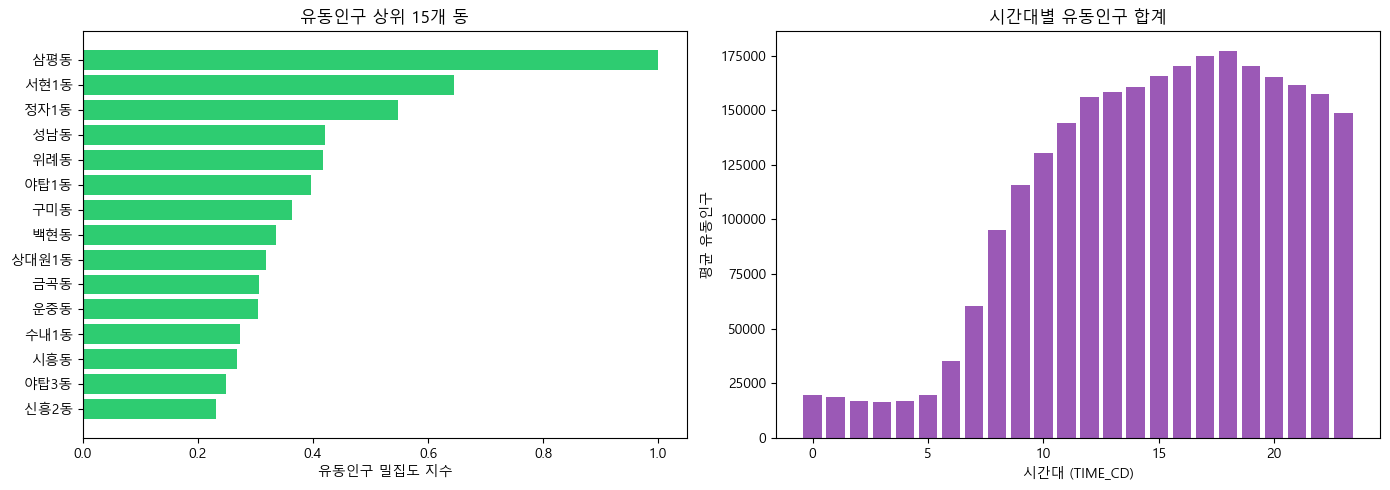

In [6]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 왼쪽: 동별 유동인구 지수 상위 15개
top15 = pop_by_dong.nlargest(15, "flow_pop_index")
axes[0].barh(
    top15["dong_nm"][::-1],
    top15["flow_pop_index"][::-1],
    color="#2ecc71",
)
axes[0].set_xlabel("유동인구 밀집도 지수")
axes[0].set_title("유동인구 상위 15개 동")

# 오른쪽: 시간대별 전체 유동인구 패턴
hourly_total = hourly_pop.groupby("TIME_CD")["avg_total_pop"].sum()
axes[1].bar(hourly_total.index, hourly_total.values, color="#9b59b6")
axes[1].set_xlabel("시간대 (TIME_CD)")
axes[1].set_ylabel("평균 유동인구")
axes[1].set_title("시간대별 유동인구 합계")

plt.tight_layout()
plt.show()

In [7]:
# 저장
pop_by_dong.to_parquet(OUT / "flow_pop_agg.parquet", index=False)
hourly_pop.to_parquet(OUT / "flow_pop_hourly.parquet", index=False)

print("저장 완료:")
print(f"  - flow_pop_agg.parquet ({len(pop_by_dong)} rows) - 동별 유동인구 지수")
print(f"  - flow_pop_hourly.parquet ({len(hourly_pop)} rows) - 동별-시간대별 유동인구")

저장 완료:
  - flow_pop_agg.parquet (50 rows) - 동별 유동인구 지수
  - flow_pop_hourly.parquet (1200 rows) - 동별-시간대별 유동인구
